In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits import mplot3d

In [2]:
# Membaca file CSV
df = pd.read_csv('Data_Tanaman_Padi_Sumatera_version_1.csv')
df

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.00,323589.00,1627.0,82.00,26.06
1,Aceh,1994,1299699.00,329041.00,1521.0,82.12,26.92
2,Aceh,1995,1382905.00,339253.00,1476.0,82.72,26.27
3,Aceh,1996,1419128.00,348223.00,1557.0,83.00,26.08
4,Aceh,1997,1368074.00,337561.00,1339.0,82.46,26.31
...,...,...,...,...,...,...,...
219,Lampung,2016,3831923.00,390799.00,2317.6,79.40,26.45
220,Lampung,2017,4090654.00,396559.00,1825.1,77.04,26.36
221,Lampung,2018,2488641.91,511940.93,1385.8,76.05,25.50
222,Lampung,2019,2164089.33,464103.42,1706.4,78.03,27.23


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    str    
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 12.4 KB


In [4]:
X = df[['Luas Panen', 'Curah hujan']]
X.head()


,Luas Panen,Curah hujan
0,323589.0,1627.0
1,329041.0,1521.0
2,339253.0,1476.0
3,348223.0,1557.0
4,337561.0,1339.0


In [5]:
y = df['Produksi']
y.head()

0    1329536.0
1    1299699.0
2    1382905.0
3    1419128.0
4    1368074.0
Name: Produksi, dtype: float64

[INFO] Menampilkan grafik scatter plot 3D... Silakan tutup jendela grafik untuk melanjutkan proses perhitungan regresi.


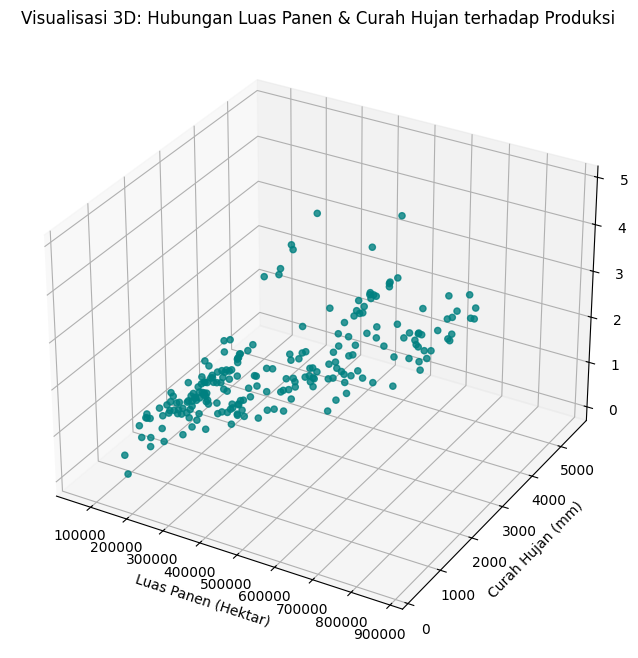

--------------------------------------------------


In [6]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

x1 = df['Luas Panen']
x2 = df['Curah hujan']

# Membuat scatter plot 3D
ax.scatter3D(x1, x2, y, color='teal', marker='o', alpha=0.8)

# Memberikan label pada sumbu grafik
ax.set_title('Visualisasi 3D: Hubungan Luas Panen & Curah Hujan terhadap Produksi')
ax.set_xlabel('Luas Panen (Hektar)')
ax.set_ylabel('Curah Hujan (mm)')
ax.set_zlabel('Produksi Padi (Ton)')

print("[INFO] Menampilkan grafik scatter plot 3D... Silakan tutup jendela grafik untuk melanjutkan proses perhitungan regresi.")
plt.show()
print("-" * 50)

In [7]:
regr = linear_model.LinearRegression()
regr.fit(X, y)

koef_luas_panen = regr.coef_[0]
koef_curah_hujan = regr.coef_[1]
konstanta = regr.intercept_

In [8]:
y_pred = regr.predict(X)
r_square = r2_score(y, y_pred)

In [9]:
def cek_arah_hubungan(koefisien, nama_variabel):
    if koefisien > 0:
        return "POSITIF (+)", f"Setiap kenaikan {nama_variabel} akan cenderung meningkatkan Produksi Padi."
    elif koefisien < 0:
        return "NEGATIF (-)", f"Setiap kenaikan {nama_variabel} akan cenderung menurunkan Produksi Padi."
    else:
        return "NETRAL (0)", f"Perubahan {nama_variabel} tidak berpengaruh terhadap Produksi Padi."

status_luas, arti_luas = cek_arah_hubungan(koef_luas_panen, "Luas Panen")
status_curah, arti_curah = cek_arah_hubungan(koef_curah_hujan, "Curah Hujan")

In [10]:

print("=== HASIL ANALISIS REGRESI BERGANDA ===")
print(f"Koefisien Luas Panen (b1) : {koef_luas_panen:.6f}")
print(f"Koefisien Curah Hujan (b2): {koef_curah_hujan:.6f}")
print(f"Konstanta (a)             : {konstanta:.6f}")
print("\nPersamaan Matematika yang Terbentuk:")
print(f"y = {konstanta:.4f} + ({koef_luas_panen:.4f} * Luas Panen) + ({koef_curah_hujan:.4f} * Curah Hujan)")
print("-" * 50)

print("\n=== NILAI R-SQUARED (AKURASI MODEL) ===")
print(f"Nilai R-squared (R²)      : {r_square:.6f}")
print(f"Akurasi Model             : {r_square * 100:.2f}%")
print(f"Penjelasan: Sebesar {r_square * 100:.2f}% variasi Produksi Padi Sumatera dapat dijelaskan")
print(f"            oleh Luas Panen dan Curah Hujan secara bersama-sama.")
print("-" * 66)

print("=== ANALISIS ARAH HUBUNGAN VARIABEL ===")
print(f"1. Hubungan Luas Panen terhadap Produksi:")
print(f"   - Arah Hubungan : {status_luas}")
print(f"   - Interpretasi  : {arti_luas}")
print()
print(f"2. Hubungan Curah Hujan terhadap Produksi:")
print(f"   - Arah Hubungan : {status_curah}")
print(f"   - Interpretasi  : {arti_curah}")
print("-" * 75)

=== HASIL ANALISIS REGRESI BERGANDA ===
Koefisien Luas Panen (b1) : 4.538584
Koefisien Curah Hujan (b2): 47.760957
Konstanta (a)             : -136451.237212

Persamaan Matematika yang Terbentuk:
y = -136451.2372 + (4.5386 * Luas Panen) + (47.7610 * Curah Hujan)
--------------------------------------------------

=== NILAI R-SQUARED (AKURASI MODEL) ===
Nilai R-squared (R²)      : 0.821937
Akurasi Model             : 82.19%
Penjelasan: Sebesar 82.19% variasi Produksi Padi Sumatera dapat dijelaskan
            oleh Luas Panen dan Curah Hujan secara bersama-sama.
------------------------------------------------------------------
=== ANALISIS ARAH HUBUNGAN VARIABEL ===
1. Hubungan Luas Panen terhadap Produksi:
   - Arah Hubungan : POSITIF (+)
   - Interpretasi  : Setiap kenaikan Luas Panen akan cenderung meningkatkan Produksi Padi.

2. Hubungan Curah Hujan terhadap Produksi:
   - Arah Hubungan : POSITIF (+)
   - Interpretasi  : Setiap kenaikan Curah Hujan akan cenderung meningkatkan Produk

In [11]:
def hitung_prediksi_rumus(luas, curah):
    prediksi = konstanta + (koef_luas_panen * luas) + (koef_curah_hujan * curah)
    return prediksi

In [12]:
luas_baru = 320000
curah_baru = 1500

produksi_via_rumus = hitung_prediksi_rumus(luas_baru, curah_baru)

print("=== CONTOH SIMULASI PREDIKSI DATA BARU ===")
print(f"Input Luas Panen             : {luas_baru:,} Hektar")
print(f"Input Curah Hujan            : {curah_baru:,} mm")
print("-" * 50)
print(f"Hasil Prediksi (Rumus Manual): {produksi_via_rumus:,.2f} Ton")
print("=========================================================")

=== CONTOH SIMULASI PREDIKSI DATA BARU ===
Input Luas Panen             : 320,000 Hektar
Input Curah Hujan            : 1,500 mm
--------------------------------------------------
Hasil Prediksi (Rumus Manual): 1,387,537.12 Ton


In [13]:
def hitung_prediksi_aman(luas, curah):
    """
    Menghitung estimasi produksi padi secara manual berdasarkan rumus:
    y = a + b1*x1 + b2*x2
    
    Dilengkapi dengan 'Safety Guard' menggunakan fungsi max() agar 
    hasil prediksi fisis tidak pernah bernilai negatif (di bawah 0 ton).
    """
    # Menghitung nilai regresi mentah sesuai rumus matematika
    prediksi_mentah = konstanta + (koef_luas_panen * luas) + (koef_curah_hujan * curah)
    
    # Pengaman: jika prediksi bernilai negatif, bulatkan menjadi 0
    prediksi_fisis_aman = max(0.0, prediksi_mentah)
    
    return prediksi_fisis_aman, prediksi_mentah

In [14]:
luas_simulasi = 320000
curah_simulasi = 1500

prod_aman, prod_mentah = hitung_prediksi_aman(luas_simulasi, curah_simulasi)

print("=== CONTOH SIMULASI PREDIKSI DATA BARU ===")
print(f"Input Luas Panen   : {luas_simulasi:,} Hektar")
print(f"Input Curah Hujan  : {curah_simulasi:,} mm")
print(f"Hasil Prediksi     : {prod_aman:,.2f} Ton")
print("===========================================================================")

=== CONTOH SIMULASI PREDIKSI DATA BARU ===
Input Luas Panen   : 320,000 Hektar
Input Curah Hujan  : 1,500 mm
Hasil Prediksi     : 1,387,537.12 Ton
